## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each LAU1 Unit ##

In [1]:
import pandas as pd
import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

enc = 'utf-8'
dec = 'greek8'

random.seed(0)
np.random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [3]:
## Reading shapefiles from Greece
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"

greece_gdf = gpd.read_file(f"{folder_path}/elladitsa.shp",  encoding=enc)
greece_regions_gdf = gpd.read_file(f"{folder_path}/perifereies2.shp",  encoding=enc)
rivers_gdf = gpd.read_file(f"{folder_path}/potamoi2.shp", encoding=enc)

In [4]:
greece_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [5]:
greece_regions_gdf.head()

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."
2,Π. ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"POLYGON ((20.77648 40.35294, 20.77652 40.35548..."
3,Π. ΗΠΕΙΡΟΥ,"MULTIPOLYGON (((20.00882 39.69130, 20.00884 39..."
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [7]:
#choose the correct region

nuts2_gdf = greece_regions_gdf.loc[greece_regions_gdf['PER'] == 'Π. ΘΕΣΣΑΛΙΑΣ']
nuts2_gdf.head()

,PER,geometry
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [8]:
indexes = []

nuts2 = nuts2_gdf

for index, row in greece_gdf.iterrows():
    for index2, row2 in nuts2.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

nuts2_gdf = greece_gdf.loc[indexes].reset_index(drop=True)

In [9]:
nuts2_gdf.head()

,NAME,KWD_YPES,geometry
0,Αγιάς,9097,"MULTIPOLYGON (((22.89063 39.67169, 22.89056 39..."
1,Αγράφων,9156,"POLYGON ((21.64628 39.24473, 21.64720 39.24471..."
2,Αλοννήσου,9109,"MULTIPOLYGON (((24.14310 39.34155, 24.14307 39..."
3,Αλμυρού,9104,"MULTIPOLYGON (((23.06753 39.00526, 23.06740 39..."
4,Αμφιλοχίας,9125,"MULTIPOLYGON (((21.15577 38.98239, 21.15567 38..."


<AxesSubplot:>

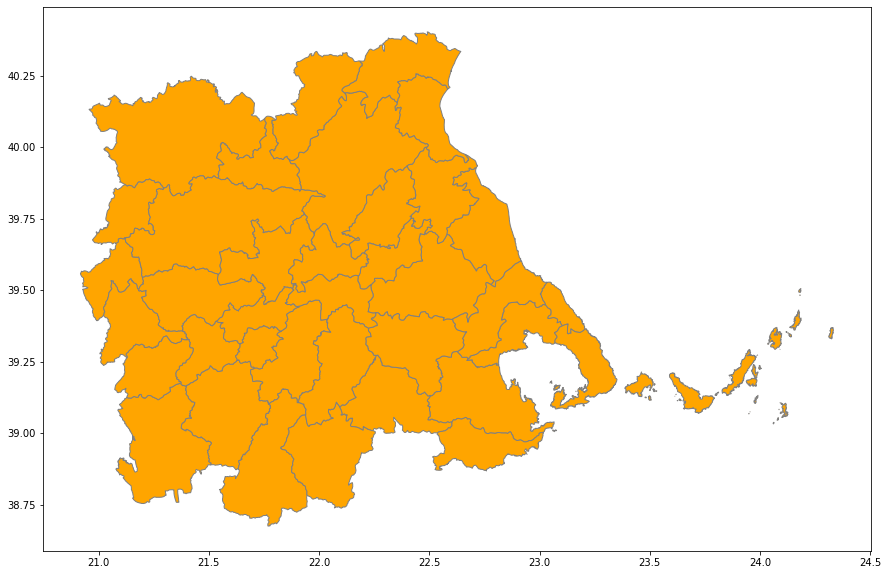

In [10]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [11]:
#check QGIS for wrong lau1 units

In [12]:
wrong_list = ['Δίου - Ολύμπου' ,'Κατερίνης', 'Σερβίων - Βελβεντού', 'Δεσκάτης', 'Γρεβενών', 'Μετσόβου', 'Βορείων Τζουμέρκων', 'Κεντρικών Τζουμέρκων',
 'Γεωργίου Καραϊσκάκη', 'Αμφιλοχίας', 'Αγράφων', 'Καρπενησίου', 'Μακρακώμης', 'Δομοκού', 'Στυλίδας']

nuts2_gdf = nuts2_gdf[~nuts2_gdf['NAME'].isin(wrong_list)].copy()

In [13]:
nuts2_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Αγιάς,9097,"MULTIPOLYGON (((22.89063 39.67169, 22.89056 39..."
2,Αλοννήσου,9109,"MULTIPOLYGON (((24.14310 39.34155, 24.14307 39..."
3,Αλμυρού,9104,"MULTIPOLYGON (((23.06753 39.00526, 23.06740 39..."
5,Αργιθέας,9091,"POLYGON ((21.43616 39.41522, 21.43830 39.41454..."
6,Βόλου,9105,"POLYGON ((22.97208 39.45655, 22.97346 39.45643..."


In [14]:
nuts2_gdf.drop(columns=['KWD_YPES'], inplace = True)
nuts2_gdf.rename(columns={"NAME": "lau1"}, inplace = True)
process_greek(nuts2_gdf, 'lau1')

In [15]:
nuts2_gdf.head(5)

,lau1,geometry
0,αγιας,"MULTIPOLYGON (((22.89063 39.67169, 22.89056 39..."
2,αλοννησου,"MULTIPOLYGON (((24.14310 39.34155, 24.14307 39..."
3,αλμυρου,"MULTIPOLYGON (((23.06753 39.00526, 23.06740 39..."
5,αργιθεας,"POLYGON ((21.43616 39.41522, 21.43830 39.41454..."
6,βολου,"POLYGON ((22.97208 39.45655, 22.97346 39.45643..."


<AxesSubplot:>

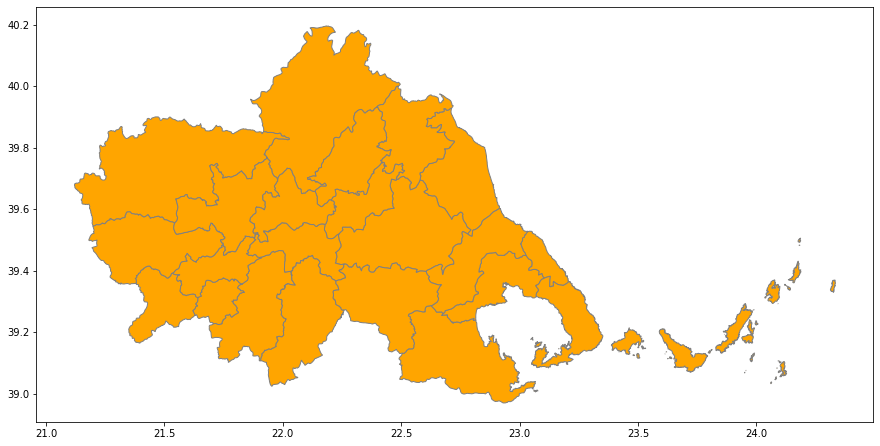

In [16]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [17]:
indexes = []

nuts2 = nuts2_gdf

for index, row in rivers_gdf.iterrows():
    for index2, row2 in nuts2.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

nuts2_rivers_gdf = rivers_gdf.loc[indexes].reset_index(drop=True)

In [18]:
nuts2_rivers_gdf.head()

,objectid,eu_cd,name,altname1,altname2,altname3,region_cd,system,ins_when,ins_by,...,acid_neut,substratum,chloride,a_temp_rge,av_a_temp,ppt,dist_sourc,cont,shape_Leng,geometry
0,3,GR0004000400260520N,ÔÁÕÑÙÐÏÓ Ð.,TAVROPOS R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,42710.979405,"LINESTRING (21.76727 39.18674, 21.76728 39.186..."
1,5,GR0008000400220360N,ÅÍÉÐÅÕÓ Ð.,ENIPEYS R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,13274.085824,"LINESTRING (22.11585 39.49631, 22.11806 39.495..."
2,5,GR0008000400220360N,ÅÍÉÐÅÕÓ Ð.,ENIPEYS R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,13274.085824,"LINESTRING (22.11585 39.49631, 22.11806 39.495..."
3,31,GR0008000400220550N,ÊÁÑÁÌÐÁËÇÓ Ð.,KARABALIS R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,4406.675683,"LINESTRING (21.93452 39.34592, 21.93566 39.346..."
4,34,GR0008000400220580N,ÐÇÍÅÉÏÓ Ð.,PINIOS R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,4406.675683,"LINESTRING (22.02974 39.55998, 22.03116 39.561..."


<AxesSubplot:>

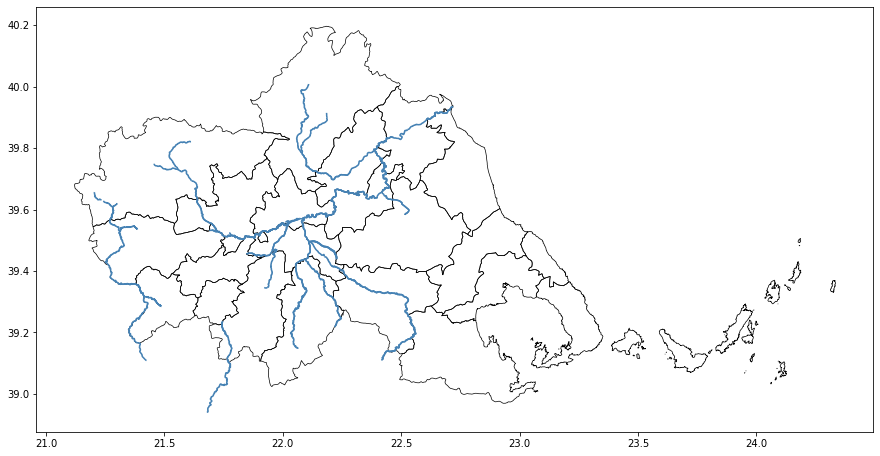

In [20]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='steelblue')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.7)

In [21]:
lau1_units = nuts2_gdf['lau1'].unique().tolist()

with open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_SHP_LAU1_Units_Processed.txt', 'w', encoding=enc) as f:
    for item in lau1_units:
        f.write("%s\n" % item)

print(f"Number of LAU1 Units in {NUTS2} (from shapefile): {len(lau1_units)}")

Number of LAU1 Units in Thessaly (from shapefile): 25


In [22]:
nuts2_gdf.reset_index(inplace=True, drop = True)
nuts2_rivers_gdf.reset_index(inplace=True, drop=True)

In [23]:
df_grid = create_grid(nuts2_rivers_gdf, nuts2_gdf, col_municipal='lau1', dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

e:\Google Drive\NOA\MBD-Prediction\Greece\notebooks\Thessaly\../../../Modules\preprocessing_utils.py:38: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\dtypes\cast.py:118: ShapelyDeprecationWarning: The array interface is deprecated and will no 

In [24]:
df_grid.rename(columns={"NAME": "lau1"}, inplace = True)

<AxesSubplot:>

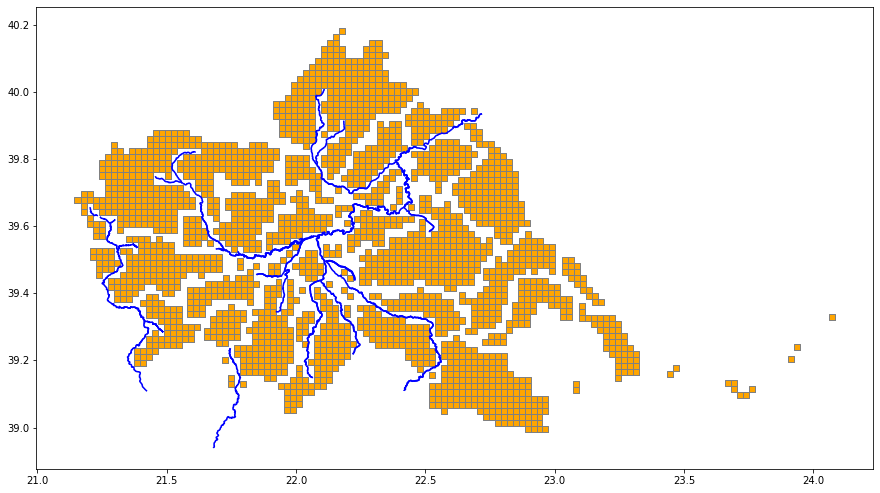

In [25]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='blue')
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [26]:
grid_lau1 = df_grid['lau1'].unique().tolist()
print(f"Number of LAU1 Units in Grid: {len(grid_lau1)}")

Number of LAU1 Units in Grid: 25


In [27]:
if (len(lau1_units) != len(grid_lau1)):
    delta = [item for item in lau1_units if item not in grid_lau1]
    print(delta)

    lost_lau1 = nuts2_gdf[nuts2_gdf['lau1'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_nuts2_grid = pd.DataFrame()
    add_to_nuts2_grid['lau1'] = lost_lau1['lau1']
    add_to_nuts2_grid['geometry'] = lost_lau1['geometry']
    add_to_nuts2_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_nuts2_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [28]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [29]:
nuts2_grid

,geometry,lau1,x,y
0,"POLYGON ((22.62551 39.69172, 22.62551 39.70969...",αγιας,22.61387,39.70070
1,"POLYGON ((22.62551 39.70969, 22.62551 39.72765...",αγιας,22.61387,39.71867
2,"POLYGON ((22.64880 39.65579, 22.64880 39.67375...",αγιας,22.63715,39.66477
3,"POLYGON ((22.64880 39.67375, 22.64880 39.69172...",αγιας,22.63715,39.68274
4,"POLYGON ((22.64880 39.69172, 22.64880 39.70969...",αγιας,22.63715,39.70070
...,...,...,...,...
2270,"POLYGON ((22.60653 39.36391, 22.60653 39.38188...",φαρσαλων,22.59495,39.37290
2271,"POLYGON ((22.62969 39.29205, 22.62969 39.31001...",φαρσαλων,22.61811,39.30103
2272,"POLYGON ((22.62969 39.31001, 22.62969 39.32798...",φαρσαλων,22.61811,39.31900
2273,"POLYGON ((22.62969 39.32798, 22.62969 39.34595...",φαρσαλων,22.61811,39.33696


In [30]:
if (len(lau1_units) != len(grid_lau1)):
    nuts2_grid = pd.concat([nuts2_grid, add_to_nuts2_grid], axis=0)

nuts2_grid.reset_index(inplace=True, drop=True)

In [31]:
nuts2_grid['nuts2'] = NUTS2_EL

In [32]:
nuts2_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [33]:
nuts2_grid

,shape,lau1,x,y,nuts2
0,"POLYGON ((22.62551 39.69172, 22.62551 39.70969...",αγιας,22.61387,39.70070,θεσσαλιας
1,"POLYGON ((22.62551 39.70969, 22.62551 39.72765...",αγιας,22.61387,39.71867,θεσσαλιας
2,"POLYGON ((22.64880 39.65579, 22.64880 39.67375...",αγιας,22.63715,39.66477,θεσσαλιας
3,"POLYGON ((22.64880 39.67375, 22.64880 39.69172...",αγιας,22.63715,39.68274,θεσσαλιας
4,"POLYGON ((22.64880 39.69172, 22.64880 39.70969...",αγιας,22.63715,39.70070,θεσσαλιας
...,...,...,...,...,...
2270,"POLYGON ((22.60653 39.36391, 22.60653 39.38188...",φαρσαλων,22.59495,39.37290,θεσσαλιας
2271,"POLYGON ((22.62969 39.29205, 22.62969 39.31001...",φαρσαλων,22.61811,39.30103,θεσσαλιας
2272,"POLYGON ((22.62969 39.31001, 22.62969 39.32798...",φαρσαλων,22.61811,39.31900,θεσσαλιας
2273,"POLYGON ((22.62969 39.32798, 22.62969 39.34595...",φαρσαλων,22.61811,39.33696,θεσσαλιας


In [34]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [35]:
nuts2_grid_points

,shape,lau1,x,y,nuts2,geometry
0,"POLYGON ((22.62551 39.69172, 22.62551 39.70969...",αγιας,22.61387,39.70070,θεσσαλιας,POINT (22.61387 39.70070)
1,"POLYGON ((22.62551 39.70969, 22.62551 39.72765...",αγιας,22.61387,39.71867,θεσσαλιας,POINT (22.61387 39.71867)
2,"POLYGON ((22.64880 39.65579, 22.64880 39.67375...",αγιας,22.63715,39.66477,θεσσαλιας,POINT (22.63715 39.66477)
3,"POLYGON ((22.64880 39.67375, 22.64880 39.69172...",αγιας,22.63715,39.68274,θεσσαλιας,POINT (22.63715 39.68274)
4,"POLYGON ((22.64880 39.69172, 22.64880 39.70969...",αγιας,22.63715,39.70070,θεσσαλιας,POINT (22.63715 39.70070)
...,...,...,...,...,...,...
2270,"POLYGON ((22.60653 39.36391, 22.60653 39.38188...",φαρσαλων,22.59495,39.37290,θεσσαλιας,POINT (22.59495 39.37290)
2271,"POLYGON ((22.62969 39.29205, 22.62969 39.31001...",φαρσαλων,22.61811,39.30103,θεσσαλιας,POINT (22.61811 39.30103)
2272,"POLYGON ((22.62969 39.31001, 22.62969 39.32798...",φαρσαλων,22.61811,39.31900,θεσσαλιας,POINT (22.61811 39.31900)
2273,"POLYGON ((22.62969 39.32798, 22.62969 39.34595...",φαρσαλων,22.61811,39.33696,θεσσαλιας,POINT (22.61811 39.33696)


<AxesSubplot:>

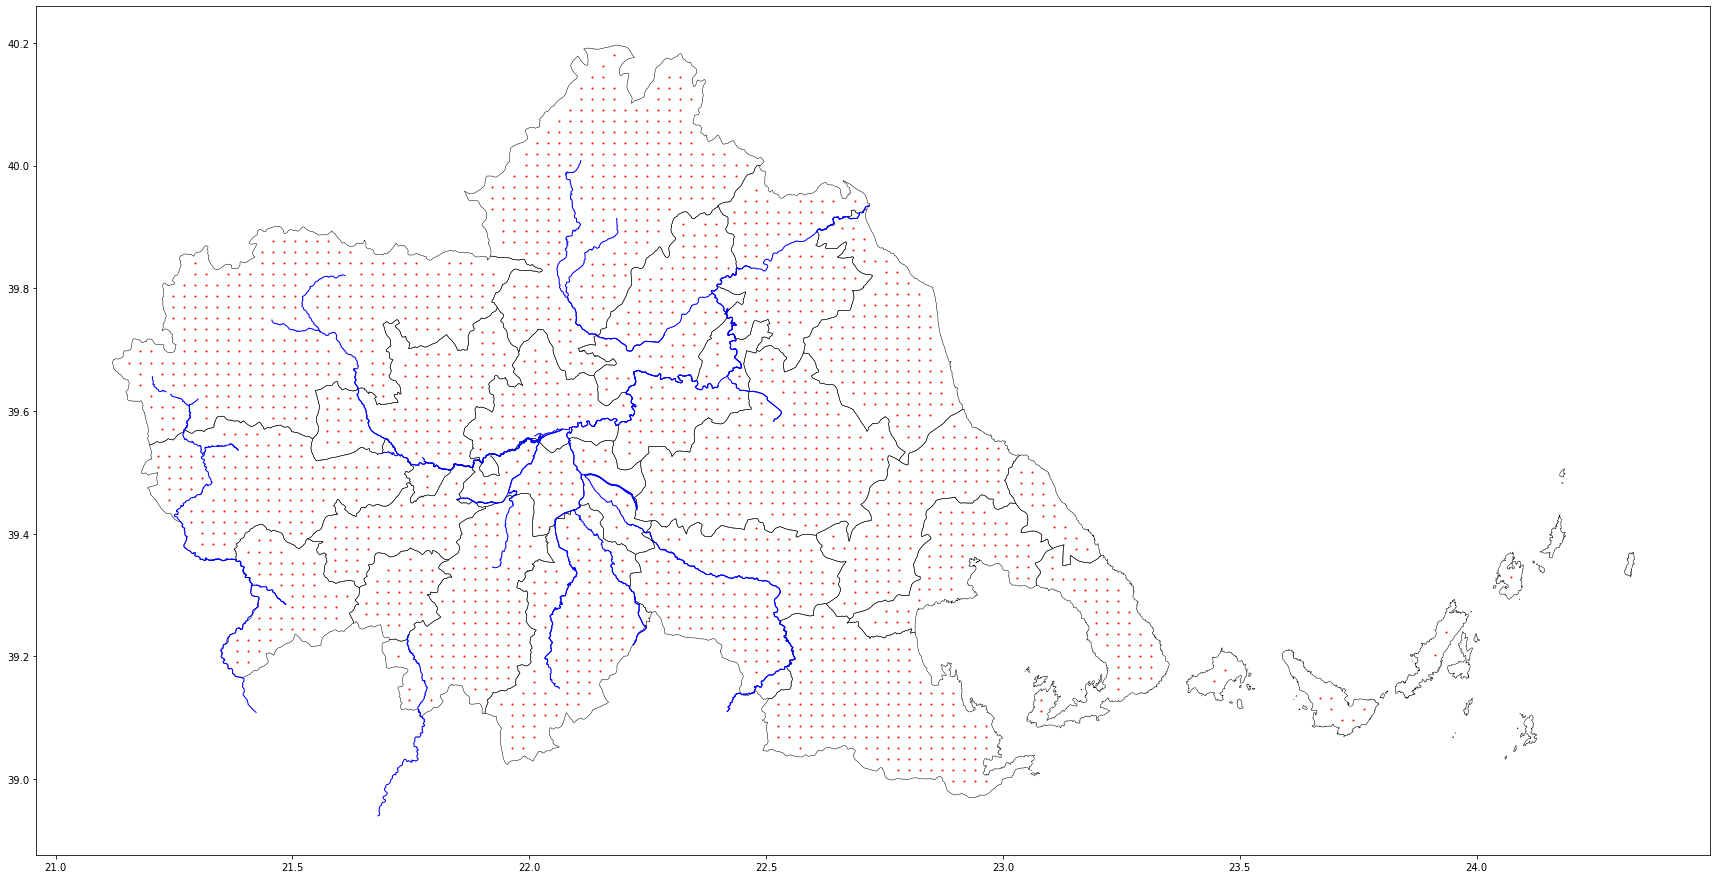

In [36]:
ax = nuts2_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [37]:
value_counts = nuts2_grid['lau1'].value_counts().sort_values()

In [38]:
arr = value_counts.values

In [39]:
arr_norm = np.ceil((15*(arr - np.min(arr) + 1 )/np.ptp(arr))).astype(int)

In [40]:
value_counts_target = pd.Series(data=arr_norm, index=value_counts.index)

In [41]:
value_counts_target

σκιαθου               1
αλοννησου             1
σκοπελου              1
ζαγορας μουρεσιου     1
λιμνης πλαστηρα       2
παλαμα                2
λαρισαιων             2
φαρκαδονας            3
μουζακιου             3
νοτιου πηλιου         3
αργιθεας              3
βολου                 3
τυρναβου              4
τεμπων                5
τρικκαιων             5
ρηγα φερραιου         5
σοφαδων               6
καρδιτσας             6
φαρσαλων              7
αγιας                 7
πυλης                 7
αλμυρου               9
κιλελερ              10
ελασσονας            14
καλαμπακας           16
dtype: int32

In [42]:
idx = []
points = [] 

for index, value in value_counts_target.iteritems():
    if value == value_counts[index]:
        pass
    else: 
        idx.append(index)
        points.append(value_counts[index] - value)
        print(f'Index: {index} || Value: {value_counts[index]} || Target Value: {value}')

Index: σκιαθου || Value: 2 || Target Value: 1
Index: αλοννησου || Value: 3 || Target Value: 1
Index: σκοπελου || Value: 6 || Target Value: 1
Index: ζαγορας μουρεσιου || Value: 19 || Target Value: 1
Index: λιμνης πλαστηρα || Value: 31 || Target Value: 2
Index: παλαμα || Value: 33 || Target Value: 2
Index: λαρισαιων || Value: 40 || Target Value: 2
Index: φαρκαδονας || Value: 47 || Target Value: 3
Index: μουζακιου || Value: 48 || Target Value: 3
Index: νοτιου πηλιου || Value: 50 || Target Value: 3
Index: αργιθεας || Value: 57 || Target Value: 3
Index: βολου || Value: 59 || Target Value: 3
Index: τυρναβου || Value: 75 || Target Value: 4
Index: τεμπων || Value: 91 || Target Value: 5
Index: τρικκαιων || Value: 94 || Target Value: 5
Index: ρηγα φερραιου || Value: 95 || Target Value: 5
Index: σοφαδων || Value: 103 || Target Value: 6
Index: καρδιτσας || Value: 107 || Target Value: 6
Index: φαρσαλων || Value: 122 || Target Value: 7
Index: αγιας || Value: 123 || Target Value: 7
Index: πυλης || Va

In [43]:
to_remove = pd.Series(data=points, index=idx)

In [44]:
to_remove

σκιαθου                1
αλοννησου              2
σκοπελου               5
ζαγορας μουρεσιου     18
λιμνης πλαστηρα       29
παλαμα                31
λαρισαιων             38
φαρκαδονας            44
μουζακιου             45
νοτιου πηλιου         47
αργιθεας              54
βολου                 56
τυρναβου              71
τεμπων                86
τρικκαιων             89
ρηγα φερραιου         90
σοφαδων               97
καρδιτσας            101
φαρσαλων             115
αγιας                116
πυλης                119
αλμυρου              170
κιλελερ              176
ελασσονας            263
καλαμπακας           286
dtype: int64

In [45]:
indicies_to_remove = []

for municipality, points in to_remove.iteritems():
    indicies = nuts2_grid.loc[nuts2_grid['lau1'] ==  municipality].index.tolist()
    to_removed = random.sample(indicies, points)
    for item in to_removed:
        indicies_to_remove.append(item)

nuts2_grid.drop(index = indicies_to_remove, axis = 1, inplace = True)
nuts2_grid.reset_index(inplace = True, drop = True)

In [46]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

<AxesSubplot:>

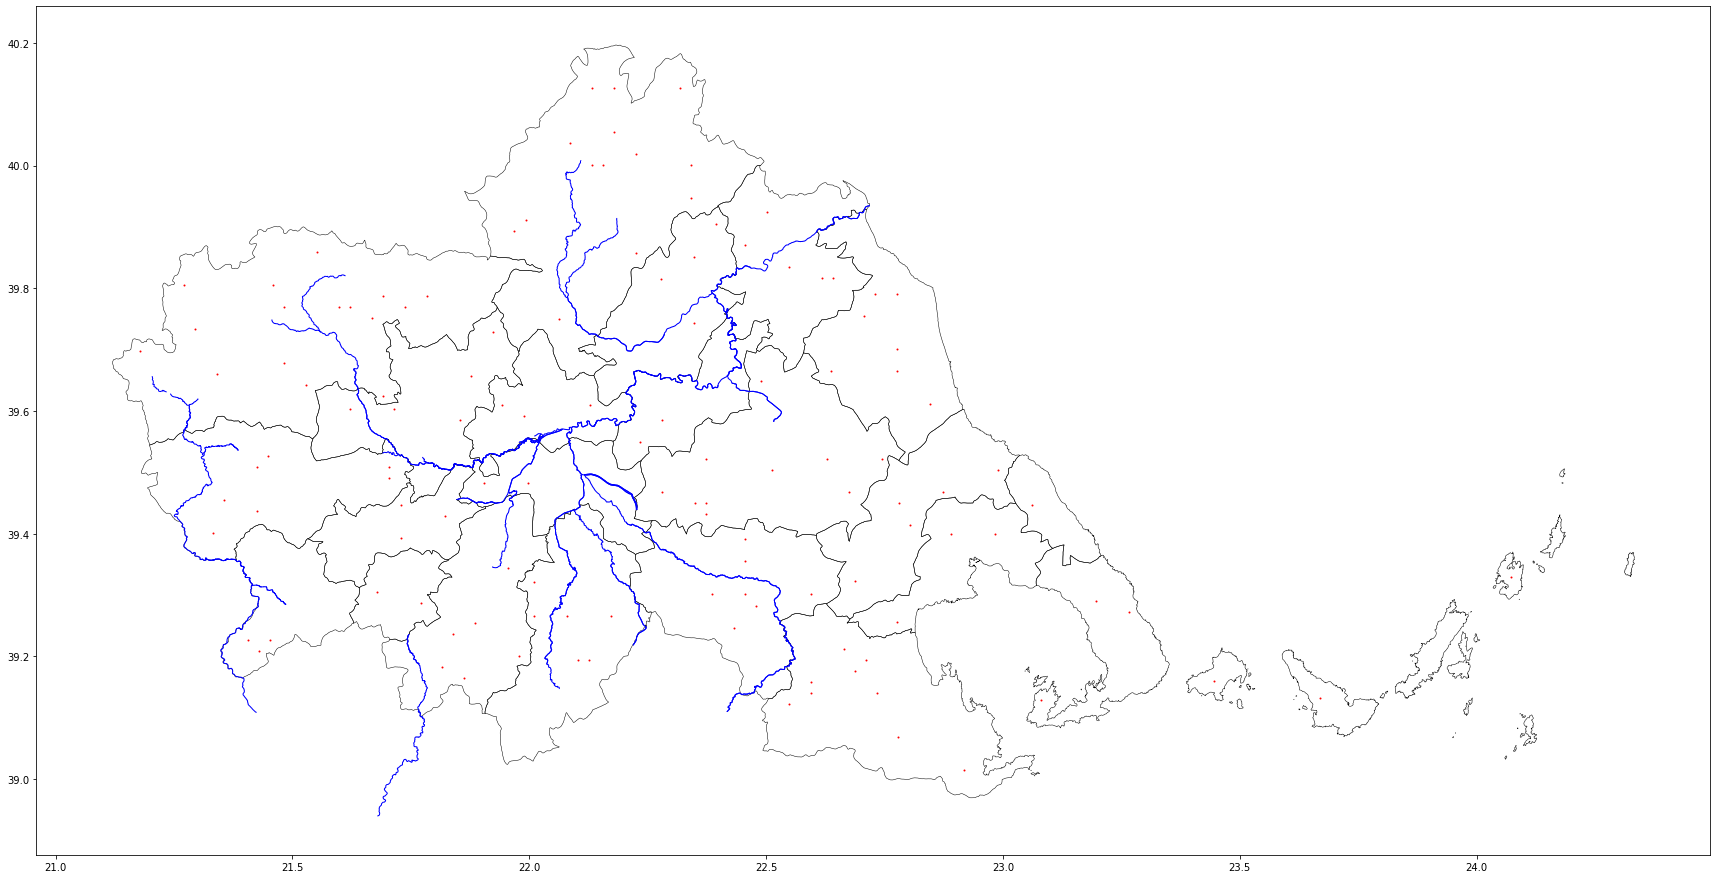

In [47]:
ax = nuts2_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [48]:
len(nuts2_grid['lau1'].unique())

25

In [49]:
nuts2_grid

,shape,lau1,x,y,nuts2,geometry
0,"POLYGON ((22.64880 39.65579, 22.64880 39.67375...",αγιας,22.63715,39.66477,θεσσαλιας,POINT (22.63715 39.66477)
1,"POLYGON ((22.71866 39.74562, 22.71866 39.76359...",αγιας,22.70702,39.75460,θεσσαλιας,POINT (22.70702 39.75460)
2,"POLYGON ((22.74195 39.78155, 22.74195 39.79952...",αγιας,22.73031,39.79054,θεσσαλιας,POINT (22.73031 39.79054)
3,"POLYGON ((22.78853 39.65579, 22.78853 39.67375...",αγιας,22.77688,39.66477,θεσσαλιας,POINT (22.77688 39.66477)
4,"POLYGON ((22.78853 39.69172, 22.78853 39.70969...",αγιας,22.77688,39.70070,θεσσαλιας,POINT (22.77688 39.70070)
...,...,...,...,...,...,...
121,"POLYGON ((22.46756 39.29205, 22.46756 39.31001...",φαρσαλων,22.45598,39.30103,θεσσαλιας,POINT (22.45598 39.30103)
122,"POLYGON ((22.46756 39.34595, 22.46756 39.36391...",φαρσαλων,22.45598,39.35493,θεσσαλιας,POINT (22.45598 39.35493)
123,"POLYGON ((22.46756 39.38188, 22.46756 39.39985...",φαρσαλων,22.45598,39.39086,θεσσαλιας,POINT (22.45598 39.39086)
124,"POLYGON ((22.49072 39.27408, 22.49072 39.29205...",φαρσαλων,22.47914,39.28306,θεσσαλιας,POINT (22.47914 39.28306)


In [50]:
final_grid = nuts2_grid[['nuts2', 'lau1', 'x', 'y']].sort_values(by=['lau1'])

In [51]:
final_grid

,nuts2,lau1,x,y
0,θεσσαλιας,αγιας,22.63715,39.66477
1,θεσσαλιας,αγιας,22.70702,39.75460
2,θεσσαλιας,αγιας,22.73031,39.79054
3,θεσσαλιας,αγιας,22.77688,39.66477
4,θεσσαλιας,αγιας,22.77688,39.70070
...,...,...,...,...
120,θεσσαλιας,φαρσαλων,22.43281,39.24713
121,θεσσαλιας,φαρσαλων,22.45598,39.30103
122,θεσσαλιας,φαρσαλων,22.45598,39.35493
123,θεσσαλιας,φαρσαλων,22.45598,39.39086


In [52]:
final_grid.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Grid.csv', encoding=enc, index = False)